# Data Acquisition and Quality Control

## Overview
This notebook downloads and validates <em>Mycobacterium tuberculosis</em> genome data for comparative genomics analysis between strains or variants of the bacterium.

In [1]:
# Import libraries and modules for setup
import os
import requests
import gzip
import shutil
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set project root directory
project_root = Path.cwd().parent
scripts_path = project_root / 'Scripts'
sys.path.append(str(scripts_path))

In [3]:
# Configure plotting aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# Verify project root path
print(f"Project root: {project_root}")
print(f"Current working directory: {Path.cwd()}")
print(f"Scripts directory exists: {scripts_path.exists()}")

Project root: C:\Users\dalto\Desktop\Education Resources\Personal\Projects\Mycobacterium_tuberculosis_Comparative_Genomics
Current working directory: C:\Users\dalto\Desktop\Education Resources\Personal\Projects\Mycobacterium_tuberculosis_Comparative_Genomics\Notebooks
Scripts directory exists: True


In [4]:
# Validate Scripts directory contents
print("Scripts directory contents:")
for file in scripts_path.glob("*.py"):
    print(f" - {file.name}")

# Check system Path
print("\nFirst 5 entries in sys.path:")
for path in sys.path[:5]:
    print(f" - {path}")

Scripts directory contents:
 - alignment_analysis.py
 - annotation_parser.py
 - download_data.py
 - genome_analyzer.py
 - integrated_analysis.py

First 5 entries in sys.path:
 - C:\Users\dalto\anaconda3\envs\mtb_comp_genomics\python314.zip
 - C:\Users\dalto\anaconda3\envs\mtb_comp_genomics\DLLs
 - C:\Users\dalto\anaconda3\envs\mtb_comp_genomics\Lib
 - C:\Users\dalto\anaconda3\envs\mtb_comp_genomics
 - 


In [5]:
def download_file(url, output_path):
    """Download a file from URL to output_path."""
    try:
        response = requests.get(url, stream=True, timeout=30)
        response.raise_for_status()
        
        with open(output_path, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        
        # Check if file is gzipped and decompress
        if output_path.suffix == '.gz' or url.endswith('.gz'):
            decompressed_path = output_path.with_suffix('')
            with gzip.open(output_path, 'rb') as f_in:
                with open(decompressed_path, 'wb') as f_out:
                    shutil.copyfileobj(f_in, f_out)
            os.remove(output_path)
            return decompressed_path
        
        return output_path
    except Exception as e:
        print(f"Error downloading {url}: {e}")
        return None

In [6]:
def calculate_gc_content(seq):
    """Calculate GC content percentage for a sequence."""
    if len(seq) == 0:
        return 0
    gc_count = seq.count('G') + seq.count('C') + seq.count('g') + seq.count('c')
    return (gc_count / len(seq)) * 100

In [7]:
class MTBDataDownloader:
    
    def __init__(self, project_root):
        self.project_root = project_root
        self.data_dir = project_root / "Data" / "Raw"
        self.data_dir.mkdir(parents=True, exist_ok=True)
        
        # Define URLs for H37Rv and CDC1551 genomes
        self.genome_urls = {
            'H37Rv': {
                'fasta': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/195/955/GCF_000195955.2_ASM19595v2/GCF_000195955.2_ASM19595v2_genomic.fna.gz',
                'gbff': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/195/955/GCF_000195955.2_ASM19595v2/GCF_000195955.2_ASM19595v2_genomic.gbff.gz',
                'gff': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/195/955/GCF_000195955.2_ASM19595v2/GCF_000195955.2_ASM19595v2_genomic.gff.gz'
            },
            'CDC1551': {
                'fasta': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/007/545/GCF_000007545.1_ASM754v1/GCF_000007545.1_ASM754v1_genomic.fna.gz',
                'gbff': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/007/545/GCF_000007545.1_ASM754v1/GCF_000007545.1_ASM754v1_genomic.gbff.gz',
                'gff': 'https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/007/545/GCF_000007545.1_ASM754v1/GCF_000007545.1_ASM754v1_genomic.gff.gz'
            }
        }
    
    def download_all_genomes(self):
        """Download all genome files."""
        results = {}
        
        for strain, urls in self.genome_urls.items():
            strain_results = {}
            
            for file_type, url in urls.items():
                output_filename = f"{strain}_{'fasta' if file_type == 'fasta' else 'gbff' if file_type == 'gbff' else 'gff'}"
                output_filename += '.fna' if file_type == 'fasta' else '.gbff' if file_type == 'gbff' else '.gff'
                output_path = self.data_dir / output_filename
                
                # Check if file already exists
                if output_path.exists():
                    print(f"✓ {strain} {file_type} already exists")
                    strain_results[file_type] = str(output_path)
                    continue
                
                print(f"Downloading {strain} {file_type}...")
                downloaded_path = download_file(url, output_path)
                
                if downloaded_path:
                    strain_results[file_type] = str(downloaded_path)
                    print(f"✓ Downloaded {strain} {file_type}")
                else:
                    strain_results[file_type] = None
                    print(f"✗ Failed to download {strain} {file_type}")
            
            results[strain] = strain_results
        
        return results

In [8]:
class GenomeAnalyzer:
    """Analyze genome data."""
    
    def __init__(self, project_root):
        self.project_root = project_root
        self.data_dir = project_root / "Data" / "Raw"
    
    def load_genome(self, strain):
        """Load genome from FASTA file."""
        fasta_path = self.data_dir / f"{strain}_fasta.fna"
        
        if not fasta_path.exists():
            raise FileNotFoundError(f"FASTA file not found for {strain}")
        
        records = list(SeqIO.parse(fasta_path, "fasta"))
        return records
    
    def calculate_basic_stats(self, records):
        """Calculate basic statistics for genome records."""
        if not records:
            return {}
        
        # Get contig lengths
        contig_lengths = sorted([len(rec.seq) for rec in records], reverse=True)
        total_length = sum(contig_lengths)
        
        # Calculate GC content
        gc_total = 0
        for rec in records:
            gc_total += calculate_gc_content(rec.seq) * len(rec.seq)
        gc_content = (gc_total / total_length) if total_length > 0 else 0
        
        # Calculate N50, N75, L50
        n50 = self._calculate_nx(contig_lengths, total_length, 50)
        n75 = self._calculate_nx(contig_lengths, total_length, 75)
        l50 = self._calculate_lx(contig_lengths, total_length, 50)
        
        return {
            'total_length': total_length,
            'gc_content': gc_content,
            'num_contigs': len(contig_lengths),
            'n50': n50,
            'n75': n75,
            'l50': l50,
            'min_contig_length': min(contig_lengths),
            'max_contig_length': max(contig_lengths),
            'contig_lengths': contig_lengths
        }
    
    def _calculate_nx(self, lengths, total, x):
        """Calculate N50, N75, etc."""
        if not lengths:
            return 0
        
        target_length = total * (x / 100)
        cumulative = 0
        
        for length in lengths:
            cumulative += length
            if cumulative >= target_length:
                return length
        
        return lengths[-1]
    
    def _calculate_lx(self, lengths, total, x):
        """Calculate L50, L75, etc."""
        if not lengths:
            return 0
        
        target_length = total * (x / 100)
        cumulative = 0
        count = 0
        
        for length in lengths:
            cumulative += length
            count += 1
            if cumulative >= target_length:
                return count
        
        return len(lengths)
    
    def compare_genomes(self, stats1, stats2):
        """Compare two genome statistics."""
        return {
            'stats1': stats1,
            'stats2': stats2,
            'length_difference': abs(stats1['total_length'] - stats2['total_length']),
            'length_ratio': stats1['total_length'] / stats2['total_length'] if stats2['total_length'] > 0 else 0,
            'gc_difference': abs(stats1['gc_content'] - stats2['gc_content']),
            'contig_difference': abs(stats1['num_contigs'] - stats2['num_contigs'])
        }

## Download Genome Data

Download M. tuberculosis genome data for H37Rv (reference strain) and CDC1551 (clinical strain) from NCBI.

In [9]:
# Initialize the downloader
downloader = MTBDataDownloader(project_root)
print("Starting data download from NCBI...")
results = downloader.download_all_genomes()

# Display download summary
df_summary = pd.DataFrame(results).T
display(df_summary)

Starting data download from NCBI...
✓ H37Rv fasta already exists
✓ H37Rv gbff already exists
✓ H37Rv gff already exists
✓ CDC1551 fasta already exists
✓ CDC1551 gbff already exists
✓ CDC1551 gff already exists


,fasta,gbff,gff
H37Rv,C:\Users\dalto\Desktop\Education Resources\Per...,C:\Users\dalto\Desktop\Education Resources\Per...,C:\Users\dalto\Desktop\Education Resources\Per...
CDC1551,C:\Users\dalto\Desktop\Education Resources\Per...,C:\Users\dalto\Desktop\Education Resources\Per...,C:\Users\dalto\Desktop\Education Resources\Per...


## Verify Downloaded Files

Check that all required files are present and validate their integrity.

In [10]:
def verify_downloaded_files(strain):
    """Verify and display information about downloaded files."""
    raw_dir = project_root / "Data" / "Raw"

    print(f"\n{'='*40}")
    print(f"Verifying {strain} files:")
    print(f'{'='*40}')

    files = {
        'FASTA': raw_dir / f"{strain}_fasta.fna",
        'GBFF': raw_dir / f"{strain}_gbff.gbff",
        'GFF3': raw_dir / f"{strain}_gff.gff",
    }

    for file_type, file_path in files.items():
        if file_path.exists():
            file_size = file_path.stat().st_size / (1024**2)
            print(f"✓ {file_type}: {file_path.name} ({file_size:.2f} MB)")
        else:
            print(f"✗ {file_type}: File not found")
    return all(file_path.exists() for file_path in files.values())

In [11]:
# Verify both strains
for strain in ['H37Rv', 'CDC1551']:
    verify_downloaded_files(strain)


Verifying H37Rv files:
✓ FASTA: H37Rv_fasta.fna (4.26 MB)
✓ GBFF: H37Rv_gbff.gbff (9.80 MB)
✓ GFF3: H37Rv_gff.gff (2.07 MB)

Verifying CDC1551 files:
✓ FASTA: CDC1551_fasta.fna (4.25 MB)
✓ GBFF: CDC1551_gbff.gbff (10.56 MB)
✓ GFF3: CDC1551_gff.gff (2.28 MB)


## Explore FASTA Files

Examine basic characteristics of the genome sequences.

In [12]:
def gc_fraction(seq):
    """Calculate GC fraction for a sequence (workaround for Bio.SeqUtils.GC)."""
    if len(seq) == 0:
        return 0
    gc_count = seq.count('G') + seq.count('C') + seq.count('g') + seq.count('c')
    return gc_count / len(seq)

In [13]:
def explore_fasta_file(strain):
    """Explore basic characteristics of FASTA file."""
    fasta_path = project_root / "Data" / "Raw" / f"{strain}_fasta.fna"

    if not fasta_path.exists():
        print(f"FASTA file not found for {strain}.")
        return None
    
    records = list(SeqIO.parse(fasta_path, "fasta"))

    print(f"\n{strain} Genome Summary:")
    print(f"{'='*40}")
    print(f"Number of contigs: {len(records)}")

    contig_lengths = [len(record.seq) for record in records]
    total_length = sum(contig_lengths)
    print(f"Total length: {total_length:,} bp")
    print(f"Contig lengths (top 3): {[f'{l:,}' for l in sorted(contig_lengths, reverse=True)[:3]]}...")

    # Calculate GC content with workaround function
    gc_total = 0
    for rec in records:
        gc_total += gc_fraction(rec.seq) * len(rec.seq)
    gc_content = (gc_total / total_length) * 100
    print(f"GC Content: {gc_content:.2f}%")

    # Display first contig info
    print(f"\nFirst Contig ({records[0].id}):")
    print(f"Length: {len(records[0].seq):,} bp")
    print(f"First 50 bases: {records[0].seq[:50]}")
    print(f"Last 50 bases: {records[0].seq[-50:]}")

    return records

In [14]:
# Explore both genomes
h37rv_records = explore_fasta_file("H37Rv")
cdc1551_records = explore_fasta_file("CDC1551")


H37Rv Genome Summary:
Number of contigs: 1
Total length: 4,411,532 bp
Contig lengths (top 3): ['4,411,532']...
GC Content: 65.61%

First Contig (NC_000962.3):
Length: 4,411,532 bp
First 50 bases: TTGACCGATGACCCCGGTTCAGGCTTCACCACAGTGTGGAACGCGGTCGT
Last 50 bases: TCGACCCGGAACCAAGACCCGGAACTAACGAGAACCAGGGAGATACGTCG

CDC1551 Genome Summary:
Number of contigs: 1
Total length: 4,403,837 bp
Contig lengths (top 3): ['4,403,837']...
GC Content: 65.61%

First Contig (NC_002755.2):
Length: 4,403,837 bp
First 50 bases: TTGACCGATGACCCCGGTTCAGGCTTCACCACAGTGTGGAACGCGGTCGT
Last 50 bases: TCGACCCGGAACCAAGACCCGGAACTAACGAGAACCAGGGAGATACGTCG


## QC Checks

Perform comprehensive quality control on the downloaded data.

In [15]:
def perform_qc_checks(strain):
    """Perform quality control checks on genome data."""
    print(f"\nQuality Control for {strain}:")
    print(f"{'='*40}")

    raw_dir = project_root / "Data" / "Raw"
    checks = []

    # Check 1: File existence
    required_files = ['_fasta.fna', '_gbff.gbff', '_gff.gff']
    for suffix in required_files:
        file_path = raw_dir / f"{strain}{suffix}"
        if file_path.exists():
            checks.append(("File exists: " + suffix[1:], file_path.exists()))

    # Check 2: Basic FASTA integrity
    fasta_path = raw_dir / f"{strain}_fasta.fna"
    if fasta_path.exists():
        try:
            records = list(SeqIO.parse(fasta_path, "fasta"))
            checks.append(("FASTA parses successfully", len(records) > 0))
            if len(records) > 0:
                checks.append(("Contig count reasonable", 1 <= len(records) <= 10))
                total_length = sum(len(rec.seq) for rec in records)
                checks.append(("Genome length reasonable", 4e6 <= total_length <= 5e6))
        except Exception as e:
            checks.append(("Fasta parsing", False))
    
    # Check 3: GFF file has content
    gff_path = raw_dir / f"{strain}_gff.gff"
    if gff_path.exists():
        try:
            with open(gff_path, 'r') as f:
                lines = f.readlines()
                gene_lines = [l for l in lines if 'gene' in l or 'CDS' in l]
                checks.append(("GFF file has gene annotations", len(gene_lines) > 1000))
        except Exception as e:
            checks.append(("GFF reading", False))
    
    # Display QC results
    for check, passed in checks:
        status = "✓" if passed else "✗"
        print(f"{status} {check}")
    
    return all(passed for _, passed in checks)

In [16]:
# Perform QC checks for both strains
print("\n" + "="*60)
print("Quality Control Summary")
print("="*60)

qc_results = {}
for strain in ['H37Rv', 'CDC1551']:
    qc_results[strain] = perform_qc_checks(strain)

print(f"\nOverall QC Status:")
for strain, passed in qc_results.items():
    status = "PASS" if passed else "FAIL"
    print(f"{strain}: {status}")


Quality Control Summary

Quality Control for H37Rv:
✓ File exists: fasta.fna
✓ File exists: gbff.gbff
✓ File exists: gff.gff
✓ FASTA parses successfully
✓ Contig count reasonable
✓ Genome length reasonable
✓ GFF file has gene annotations

Quality Control for CDC1551:
✓ File exists: fasta.fna
✓ File exists: gbff.gbff
✓ File exists: gff.gff
✓ FASTA parses successfully
✓ Contig count reasonable
✓ Genome length reasonable
✓ GFF file has gene annotations

Overall QC Status:
H37Rv: PASS
CDC1551: PASS


## Analyze Genomes Using GenomeAnalyzer

Use the GenomeAnalyzer module to get detailed statistics about each genome.

In [17]:
print("Initializing GenomeAnalyzer...")
analyzer = GenomeAnalyzer(project_root)

Initializing GenomeAnalyzer...


In [18]:
# Analyze both strains
for strain in ['H37Rv', 'CDC1551']:
    print(f"\n{'=' * 40}")
    print(f"Detailed Analysis: {strain}")
    print(f"{'=' * 40}")
    try:
        records = analyzer.load_genome(strain)
        stats = analyzer.calculate_basic_stats(records)

        #Display key statistics
        print(f"Total Length: {stats['total_length']:,} bp")
        print(f"GC content: {stats['gc_content']:.2f}%")
        print(f"Number of Contigs: {stats['num_contigs']}")
        print(f"N50: {stats['n50']:,} bp")
        print(f"N75: {stats['n75']:,} bp")
        print(f"L50: {stats['l50']}")
        print(f"Contig length range: {stats['min_contig_length']:,} bp - {stats['max_contig_length']:,} bp")

    except Exception as e:
        print(f"Error analyzing {strain}: {e}")


Detailed Analysis: H37Rv
Total Length: 4,411,532 bp
GC content: 65.61%
Number of Contigs: 1
N50: 4,411,532 bp
N75: 4,411,532 bp
L50: 1
Contig length range: 4,411,532 bp - 4,411,532 bp

Detailed Analysis: CDC1551
Total Length: 4,403,837 bp
GC content: 65.61%
Number of Contigs: 1
N50: 4,403,837 bp
N75: 4,403,837 bp
L50: 1
Contig length range: 4,403,837 bp - 4,403,837 bp


## Compare Genomes

Compare the two strains to identify differences in genome characteristics.

In [19]:
# Get Stats for comparison
print("Calculating comparison statistics...")
h37rv_records = analyzer.load_genome("H37Rv")
cdc1551_records = analyzer.load_genome("CDC1551")

h37rv_stats = analyzer.calculate_basic_stats(h37rv_records)
cdc1551_stats = analyzer.calculate_basic_stats(cdc1551_records)

comparison = analyzer.compare_genomes(h37rv_stats, cdc1551_stats)

Calculating comparison statistics...


In [20]:
print(f"\nH37Rv vs CDC1551 Comparison:")
print(f"{'='*40}")
print(f"Length difference: {comparison['length_difference']:,} bp")
print(f"Length ratio (H37Rv/CDC1551): {comparison['length_ratio']:.4f}")
print(f"GC content difference: {comparison['gc_difference']:.2f}%")
print(f"Contig count difference: {comparison['contig_difference']}")


H37Rv vs CDC1551 Comparison:
Length difference: 7,695 bp
Length ratio (H37Rv/CDC1551): 1.0017
GC content difference: 0.01%
Contig count difference: 0


In [21]:
# Access Individual statistics
h37rv_stats = comparison['stats1']
cdc_stats = comparison['stats2']

print(f"\nH37Rv Statistics:")
print(f" Total Length: {h37rv_stats['total_length']:,} bp")
print(f" GC content: {h37rv_stats['gc_content']:.2f}%")

print(f"\nCDC1551 Statistics:")
print(f" Total Length: {cdc_stats['total_length']:,} bp")
print(f" GC content: {cdc_stats['gc_content']:.2f}%")


H37Rv Statistics:
 Total Length: 4,411,532 bp
 GC content: 65.61%

CDC1551 Statistics:
 Total Length: 4,403,837 bp
 GC content: 65.61%


## Create Visualizations

Generate visual comparisons of genome statistics.

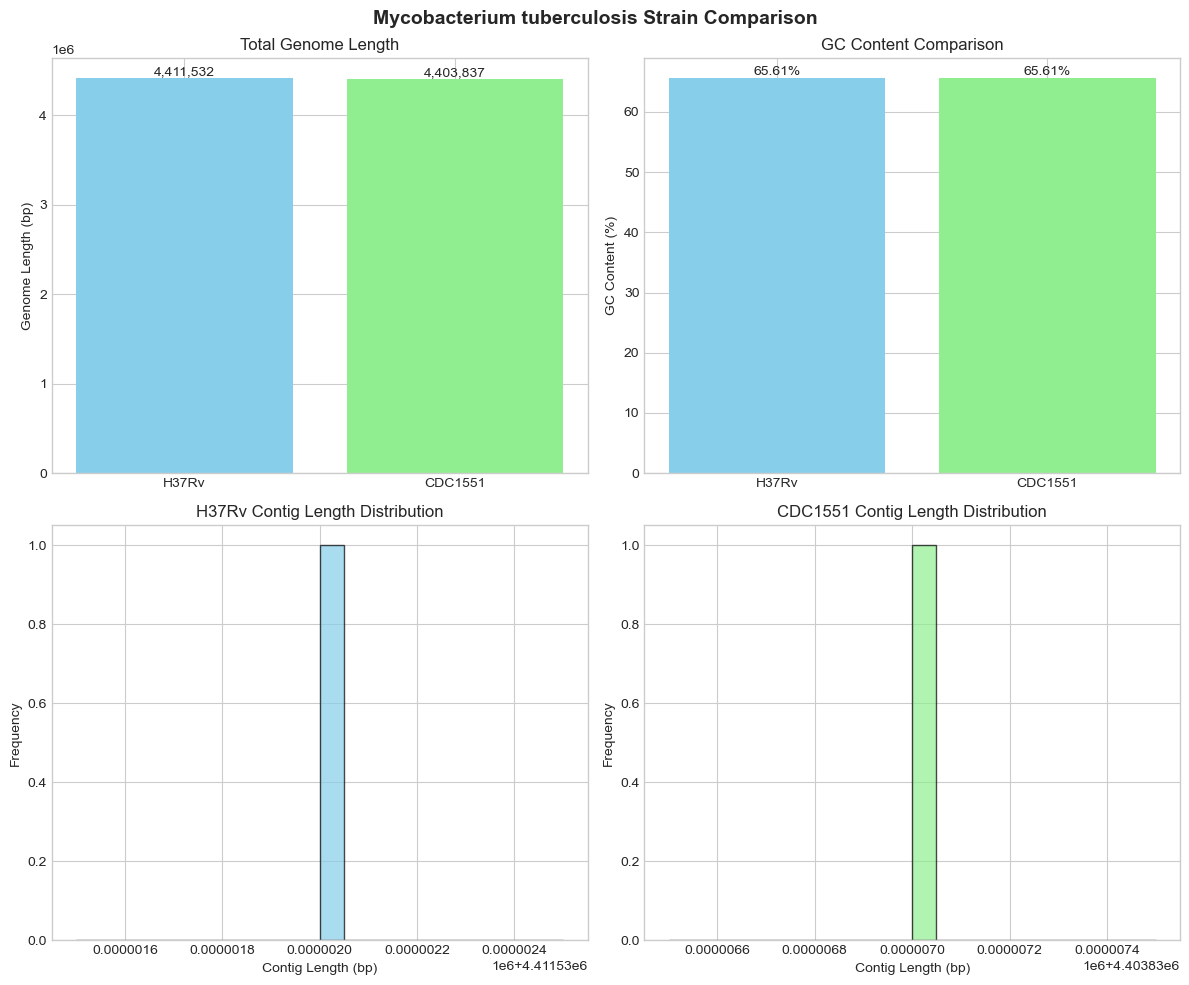

✓ Visualization saved to: C:\Users\dalto\Desktop\Education Resources\Personal\Projects\Mycobacterium_tuberculosis_Comparative_Genomics\Results\Plots\genome_statistics_comparison.png


In [22]:
# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Load stats for both strains using our inline analyzer
h37rv_records = analyzer.load_genome("H37Rv")
cdc1551_records = analyzer.load_genome("CDC1551")

h37rv_stats = analyzer.calculate_basic_stats(h37rv_records)
cdc1551_stats = analyzer.calculate_basic_stats(cdc1551_records)

# Plot 1: Contig length comparison
strains = ['H37Rv', 'CDC1551']
lengths = [h37rv_stats['total_length'], cdc1551_stats['total_length']]

axes[0, 0].bar(strains, lengths, color=['skyblue', 'lightgreen'])
axes[0, 0].set_ylabel('Genome Length (bp)')
axes[0, 0].set_title('Total Genome Length')
axes[0, 0].ticklabel_format(style='sci', axis='y', scilimits=(6,6))

# Add value labels to plot
for i, v in enumerate(lengths):
    axes[0, 0].text(i, v, f"{v:,}", ha='center', va='bottom')

# Plot 2: GC content comparison
gc_contents = [h37rv_stats['gc_content'], cdc1551_stats['gc_content']]
axes[0, 1].bar(strains, gc_contents, color=['skyblue', 'lightgreen'])
axes[0, 1].set_ylabel('GC Content (%)')
axes[0, 1].set_title('GC Content Comparison')

# Add value labels to plot
for i, v in enumerate(gc_contents):
    axes[0, 1].text(i, v, f"{v:.2f}%", ha='center', va='bottom')

# Plot 3: Contig length distribution for H37Rv
contig_lengths_h37rv = h37rv_stats['contig_lengths']
axes[1, 0].hist(contig_lengths_h37rv, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Contig Length (bp)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('H37Rv Contig Length Distribution')
axes[1, 0].ticklabel_format(style='sci', axis='x', scilimits=(6,6))

# Plot 4: Contig length distribution for CDC1551
contig_lengths_cdc = cdc1551_stats['contig_lengths']
axes[1, 1].hist(contig_lengths_cdc, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Contig Length (bp)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('CDC1551 Contig Length Distribution')
axes[1, 1].ticklabel_format(style='sci', axis='x', scilimits=(6,6))

plt.suptitle('Mycobacterium tuberculosis Strain Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()

# Save the figure
output_dir = project_root / "Results" / "Plots"
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / "genome_statistics_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved to: {output_dir / 'genome_statistics_comparison.png'}")

## Generate Summary Report

Creates a comprehensive summary of the data aquisition and process.

In [23]:
print("\n" + "="*60)
print("DATA ACQUISITION SUMMARY")
print("="*60)

# Create summary table
summary_data = []

for strain in ['H37Rv', 'CDC1551']:
    # Get file information
    raw_dir = project_root / "Data" / "Raw"
    files = {
        'FASTA': raw_dir / f"{strain}_fasta.fna",
        'GBFF': raw_dir / f"{strain}_gbff.gbff",
        'GFF3': raw_dir / f"{strain}_gff.gff",
    }
    # Calculate statistics if available
    try:
        records = analyzer.load_genome(strain)
        stats = analyzer.calculate_basic_stats(records)

        summary_data.append({
            'Strain': strain,
            'Total Length (bp)': f"{stats['total_length']:,}",
            'GC Content (%)': f"{stats['gc_content']:.2f}",
            'Num Contigs': stats['num_contigs'],
            'N50 (bp)': f"{stats['n50']:,}",
            'Files Downloaded': sum(1 for f in files.values() if f.exists()),
            'Status': 'Complete' if all(f.exists() for f in files.values()) else 'Incomplete'
        })
    except Exception as e:
        summary_data.append({
            'Strain': strain,
            'Total Length (bp)': 'N/A',
            'GC Content (%)': 'N/A',
            'Num Contigs': 'N/A',
            'N50 (bp)': 'N/A',
            'Files Downloaded': sum(1 for f in files.values() if f.exists()),
            'Status': 'Error'
        })

# Display summary table
summary_df = pd.DataFrame(summary_data)
display(summary_df)


DATA ACQUISITION SUMMARY


,Strain,Total Length (bp),GC Content (%),Num Contigs,N50 (bp),Files Downloaded,Status
0,H37Rv,"4,411,532",65.61,1,"4,411,532",3,Complete
1,CDC1551,"4,403,837",65.61,1,"4,403,837",3,Complete


In [24]:
# Save summary to file
output_file = project_root / "Results" / "data_ascuisition_summary.csv"
summary_df.to_csv(output_file, index=False)
print(f"\n✓ Summary saved to: {output_file}")
print(f"\nData acquisition and quality control complete!")


✓ Summary saved to: C:\Users\dalto\Desktop\Education Resources\Personal\Projects\Mycobacterium_tuberculosis_Comparative_Genomics\Results\data_ascuisition_summary.csv

Data acquisition and quality control complete!
